# FM Performance vs Geometric Regularization Strength

evaluates flow matching models trained in hybrid AE latent space at different
distance loss weights. weight=0 is pure reconstruction (no geometric regularization)
and larger weights enforce stricter PHATE distance preservation in the latent space.

shows the tradeoff between reconstruction quality and latent space geometry on
downstream perturbation prediction metrics.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from flatcfm.analysis import run_benchmark_suite

WEIGHTS = [0.0, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
SEEDS = [42, 43, 44, 45, 46, 47, 48, 49, 50]
# models to plot FM is always included set to ["fm", "ode"] to overlay ODE
# only weights and seeds that have trained runs for a model appear in that
# model's line so ODE with partial coverage (e.g. 3 seeds x 3 weights)
# works cleanly
MODELS = ["fm", "ode"]
RUNS_ROOT = Path("artifacts/runs")

metrics = ["mean_gene_w1", "w2_squared", "cosine_log_fc"]
group_columns = ["cell_type", "product_dose"]
reductions = ["unweighted_mean"]

metric_lower_is_better = {
    "mean_gene_w1": True,
    "w2_squared": True,
    "cosine_log_fc": False,
    "mmd": True,
}
metric_direction = {
    "mean_gene_w1": "\u2193",
    "w2_squared": "\u2193",
    "cosine_log_fc": "\u2191",
    "mmd": "\u2193",
}


def _weight_tag(weight: float) -> str:
    if weight == 0:
        return "w0"
    # format with enough decimals then strip trailing zeros so
    # w=1e-5 becomes w0p00001 and w=10 becomes w10 matches the
    # naming convention used by the sbatch scripts
    s = f"{weight:.10f}".rstrip("0").rstrip(".")
    return "w" + s.replace(".", "p")


def _experiment_name(weight: float, seed: int, model: str = "fm") -> str:
    """build the experiment name for (weight seed model) triple

    seed=42 is the default run and uses no suffix for consistency with
    existing artifacts for other seeds we append _s{seed}
    model can be fm or ode each maps to its matching experiment prefix
    """
    prefix = {"fm": "sciplex_fm_deg_geom_reg_", "ode": "sciplex_ode_deg_geom_reg_"}[model]
    base = f"{prefix}{_weight_tag(weight)}"
    return base if seed == 42 else f"{base}_s{seed}"


In [2]:
# find available trained runs across all (weight seed model) combinations
# experiments is a list of dicts with weight seed model name so downstream
# aggregation can pivot on any of those keys
experiments = []
for model in MODELS:
    for weight in WEIGHTS:
        for seed in SEEDS:
            exp_name = _experiment_name(weight, seed, model)
            exp_dir = RUNS_ROOT / exp_name
            if not exp_dir.is_dir():
                continue
            subdirs = sorted(d for d in exp_dir.iterdir() if d.is_dir())
            if not subdirs:
                continue
            latest = subdirs[-1]
            if not (latest / "predictions" / "held_out" / "predictions.h5ad").exists():
                continue
            experiments.append({"weight": weight, "seed": seed, "model": model, "name": exp_name})

if not experiments:
    raise RuntimeError("no models available -- submit the geom reg sweep first")

available_experiments = [e["name"] for e in experiments]

# coverage table per model
status = pd.DataFrame(experiments)
for model in MODELS:
    sub = status[status["model"] == model]
    if sub.empty:
        print(f"[{model}] no runs found")
        continue
    cov = sub.pivot_table(index="seed", columns="weight", values="name", aggfunc="count", fill_value=0)
    print(f"[{model}] coverage runs per (seed weight):")
    display(cov)

print(f"\n{len(experiments)} total runs across {len(MODELS)} model types")


[fm] coverage runs per (seed weight):


weight,0.00000,0.00001,0.00010,0.00100,0.01000,0.10000,1.00000,10.00000,100.00000
seed,,,,,,,,,
42,1,1,1,1,1,1,1,1,1
43,1,1,1,1,1,1,1,1,1
44,1,1,1,1,1,1,1,1,1
45,1,0,0,0,0,0,0,0,0
46,1,0,0,0,0,0,0,0,0
47,1,0,0,0,0,0,0,0,0
48,1,0,0,0,0,0,0,0,0
49,1,0,0,0,0,0,0,0,0
50,1,0,0,0,0,0,0,0,0


[ode] coverage runs per (seed weight):


weight,0.0000,0.0001,0.0100,1.0000,10.0000,100.0000
seed,,,,,,
42,1,1,1,1,1,1
43,1,1,1,1,1,1
44,1,1,1,1,1,1
45,1,0,0,0,0,0
46,1,0,0,0,0,0
47,1,0,0,0,0,0
48,1,0,0,0,0,0
49,1,0,0,0,0,0
50,1,0,0,0,0,0



57 total runs across 2 model types


In [3]:
# evaluate FM models (cached by prediction fingerprint)
import hashlib

CACHE_DIR = Path("artifacts/geom_reg_sweep_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def _predictions_fingerprint(experiments: list[str]) -> str:
    parts = []
    for exp in sorted(experiments):
        exp_dir = RUNS_ROOT / exp
        subdirs = sorted(d for d in exp_dir.iterdir() if d.is_dir())
        if not subdirs:
            continue
        pred_path = subdirs[-1] / "predictions" / "held_out" / "predictions.h5ad"
        if pred_path.exists():
            parts.append(f"{pred_path}:{pred_path.stat().st_mtime}")
    return hashlib.sha256("|".join(parts).encode()).hexdigest()[:12]


cache_key = _predictions_fingerprint(available_experiments)
per_group_cache = CACHE_DIR / f"per_group_seeds_{cache_key}.parquet"

EVAL_BATCH_SIZE = 8  # keep peak memory manageable 57 runs at 300 MB each is ~18 GB

if per_group_cache.exists():
    per_group = pd.read_parquet(per_group_cache)
    print(f"loaded cached results ({cache_key})")
    print(f"per group rows: {len(per_group)}")
else:
    import gc

    pieces = []
    n_batches = (len(available_experiments) + EVAL_BATCH_SIZE - 1) // EVAL_BATCH_SIZE
    for bi in range(n_batches):
        batch = available_experiments[bi * EVAL_BATCH_SIZE : (bi + 1) * EVAL_BATCH_SIZE]
        print(f"  batch {bi + 1}/{n_batches}: {len(batch)} experiments")
        result = run_benchmark_suite(
            {
                "experiments": batch,
                "metrics": ["mean_gene_w1", "w2_squared", "cosine_log_fc"],
                "group_columns": group_columns,
                "reductions": reductions,
            }
        )
        pieces.append(result["per_group_metrics"])
        del result
        gc.collect()
    per_group = pd.concat(pieces, ignore_index=True)
    per_group.to_parquet(per_group_cache)
    print(f"saved results to cache ({cache_key})")
    print(f"per group rows: {len(per_group)}")

# attach weight and seed columns so downstream aggregation can group
name_to_weight_seed = {e["name"]: (e["weight"], e["seed"]) for e in experiments}
per_group["weight"] = per_group["model_name"].map(lambda n: name_to_weight_seed.get(n, (np.nan, np.nan))[0])
per_group["seed"] = per_group["model_name"].map(lambda n: name_to_weight_seed.get(n, (np.nan, np.nan))[1])

  batch 1/8: 8 experiments


/home/dac227/scratch_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/dac227/scratch_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/dac227/scratch_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/dac227/scratch_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/da

  batch 2/8: 8 experiments


/home/dac227/scratch_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/dac227/scratch_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/dac227/scratch_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/dac227/scratch_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/da

  batch 3/8: 8 experiments


...

  batch 7/8: 8 experiments


/home/dac227/scratch_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/dac227/scratch_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/dac227/scratch_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/dac227/scratch_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/da

  batch 8/8: 1 experiments


/home/dac227/scratch_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/dac227/scratch_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/dac227/scratch_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/dac227/scratch_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/da

saved results to cache (96af7228d9d2)
per group rows: 64131


In [4]:
# two level aggregation first per (weight seed model metric) then across
# seeds for error bars note each (weight seed) combination may have
# different model types present (e.g. only FM at some weights) the
# groupby handles that naturally

per_run_rows = []
for exp in experiments:
    for metric in metrics:
        subset = per_group[
            (per_group["model_name"] == exp["name"])
            & (
                (per_group["metric_base"] == metric)
                if "metric_base" in per_group.columns
                else (per_group["metric"] == metric)
            )
        ]
        if subset.empty:
            subset = per_group[(per_group["model_name"] == exp["name"]) & (per_group["metric"] == metric)]
        if subset.empty:
            continue
        per_run_rows.append(
            {
                "weight": exp["weight"],
                "seed": exp["seed"],
                "model": exp["model"],
                "metric": metric,
                "per_run_mean": subset["value"].mean(),
                "per_run_std": subset["value"].std(),
                "n_groups": len(subset),
            }
        )
per_run_df = pd.DataFrame(per_run_rows)

# cross-seed aggregation now keyed on (weight model)
agg_rows = []
for (weight, model, metric), grp in per_run_df.groupby(["weight", "model", "metric"]):
    n_seeds = len(grp)
    mean_across_seeds = grp["per_run_mean"].mean()
    if n_seeds > 1:
        std_across_seeds = grp["per_run_mean"].std()
    else:
        std_across_seeds = grp["per_run_std"].iloc[0]
    agg_rows.append(
        {
            "weight": weight,
            "model": model,
            "metric": metric,
            "mean": mean_across_seeds,
            "std": std_across_seeds,
            "n_seeds": n_seeds,
            "std_kind": "across seeds" if n_seeds > 1 else "per group (single seed)",
        }
    )
fm_df = pd.DataFrame(agg_rows).sort_values(["model", "metric", "weight"]).reset_index(drop=True)

print("per run means by model x seed (cosine_log_fc):")
display(
    per_run_df[per_run_df["metric"] == "cosine_log_fc"]
    .pivot_table(index=["model", "seed"], columns="weight", values="per_run_mean")
    .round(4)
)

print("\ncross seed aggregates (what plots use):")
display(fm_df.pivot_table(index=["model", "weight"], columns="metric", values="mean").round(4))


per run means by model x seed (cosine_log_fc):


weight      0.00000    0.00001    0.00010    0.00100    0.01000    0.10000    \
model seed                                                                     
fm    42       0.1636     0.1458     0.1391     0.1360     0.1371     0.1407   
      43       0.0546     0.1574     0.1658     0.1564     0.1713     0.1544   
      44       0.0488     0.1644     0.1636     0.1517     0.1717     0.1634   
      45       0.0471        NaN        NaN        NaN        NaN        NaN   
      46       0.1579        NaN        NaN        NaN        NaN        NaN   
      47       0.1375        NaN        NaN        NaN        NaN        NaN   
      48       0.1544        NaN        NaN        NaN        NaN        NaN   
      49       0.1796        NaN        NaN        NaN        NaN        NaN   
      50       0.1643        NaN        NaN        NaN        NaN        NaN   
ode   42       0.0566        NaN     0.0565        NaN     0.1002        NaN   
      43       0.0546        NaN     0.0969        NaN     0.1200        NaN   
      44       0.0488        NaN     0.0691        NaN     0.0854        NaN   
      45       0.0471        NaN        NaN        NaN        NaN        NaN   
      46       0.0750        NaN        NaN        NaN        NaN        NaN   
      47       0.0870        NaN        NaN        NaN        NaN        NaN   
      48       0.0831        NaN        NaN        NaN        NaN        NaN   
      49       0.0668        NaN        NaN        NaN        NaN        NaN   
      50       0.0510        NaN        NaN        NaN        NaN        NaN   

weight      1.00000    10.00000   100.00000  
model seed                                   
fm    42       0.1391     0.1545     0.1459  
      43       0.1800     0.1926     0.1830  
      44       0.1637     0.1845     0.1777  
      45          NaN        NaN        NaN  
      46          NaN        NaN        NaN  
      47          NaN        NaN        NaN  
      48          NaN        NaN        NaN  
      49          NaN        NaN        NaN  
      50          NaN        NaN        NaN  
ode   42       0.1240     0.1430     0.1489  
      43       0.1363     0.1138     0.1314  
      44       0.1332     0.1464     0.1192  
      45          NaN        NaN        NaN  
      46          NaN        NaN        NaN  
      47          NaN        NaN        NaN  
      48          NaN        NaN        NaN  
      49          NaN        NaN        NaN  
      50          NaN        NaN        NaN


cross seed aggregates (what plots use):


metric           cosine_log_fc  mean_gene_w1  w2_squared
model weight                                            
fm    0.00000           0.1231        0.2634   2251.7421
      0.00001           0.1559        0.2337   2162.6293
      0.00010           0.1562        0.2244   2194.1414
      0.00100           0.1480        0.2287   2192.4962
      0.01000           0.1600        0.2356   2169.2965
      0.10000           0.1528        0.2417   2147.8925
      1.00000           0.1609        0.2476   2129.4491
      10.00000          0.1772        0.2506   2126.3230
      100.00000         0.1689        0.2507   2129.5227
ode   0.00000           0.0633        0.2693   2413.1681
      0.00010           0.0742        0.2332   2211.3439
      0.01000           0.1019        0.2346   2178.7369
      1.00000           0.1312        0.2445   2135.0584
      10.00000          0.1344        0.2422   2130.3591
      100.00000         0.1332        0.2427   2134.9400

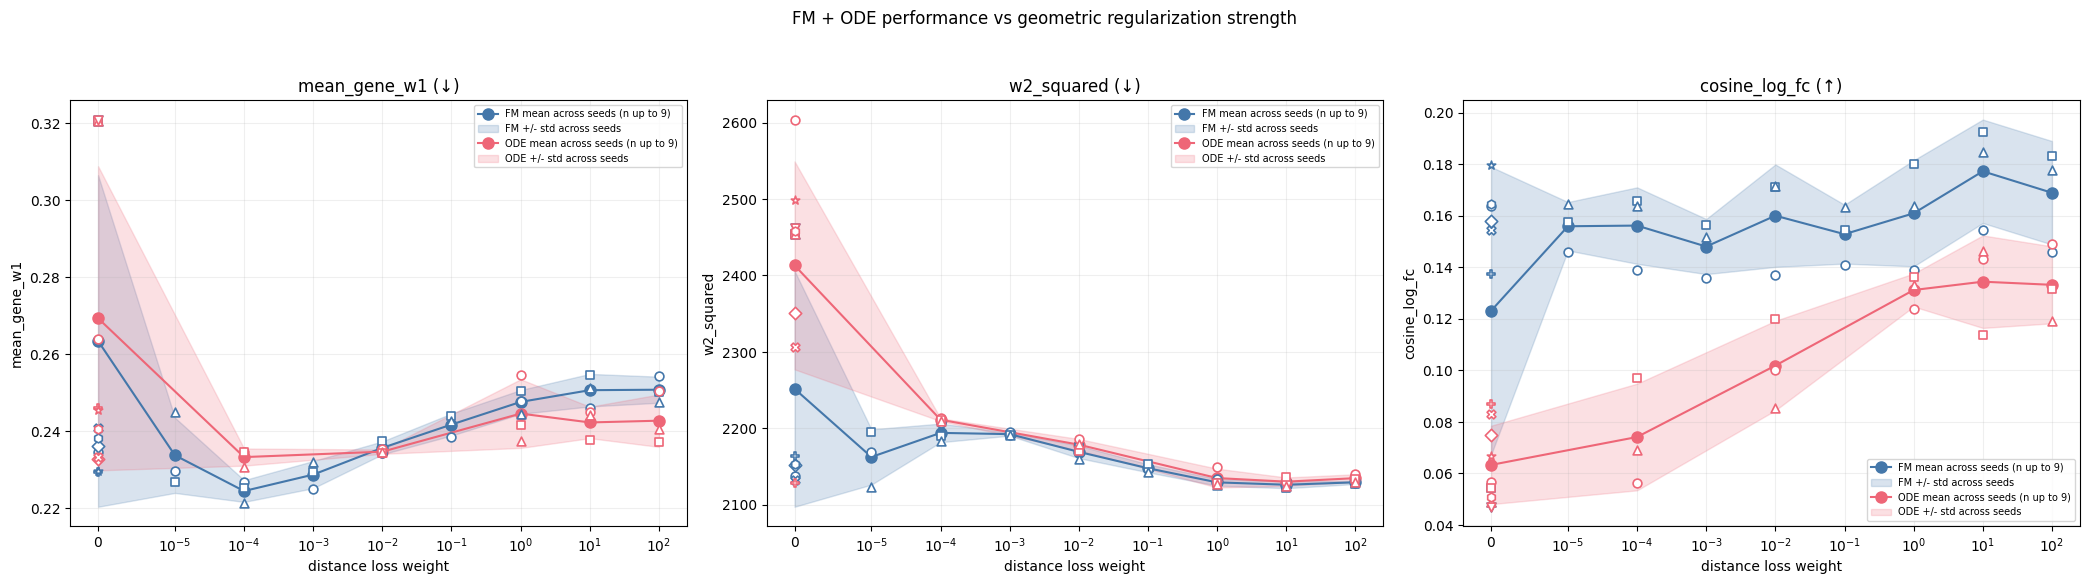

In [5]:
# plot FM and ODE (if present) on the same axes with distinct colors
# each model gets its own mean line and shaded band
plot_metrics = [m for m in metrics if m in fm_df["metric"].unique()]
n_metrics = len(plot_metrics)
ncols = 3
nrows = (n_metrics + 1) // 2

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
axes = np.array(axes).flatten()

seed_markers = {42: "o", 43: "s", 44: "^", 45: "v", 46: "D", 47: "P", 48: "X", 49: "*", 50: "h"}
model_colors = {"fm": "#4477AA", "ode": "#EE6677"}

for ax_idx, metric in enumerate(plot_metrics):
    ax = axes[ax_idx]

    for model in MODELS:
        mdf = fm_df[(fm_df["metric"] == metric) & (fm_df["model"] == model)].sort_values("weight")
        if mdf.empty:
            continue
        color = model_colors.get(model, None)
        weights = mdf["weight"].to_numpy()

        ax.plot(
            weights,
            mdf["mean"],
            marker="o",
            color=color,
            label=f"{model.upper()} mean across seeds (n up to {int(mdf['n_seeds'].max())})",
            markersize=8,
            zorder=3,
        )
        ax.fill_between(
            weights,
            mdf["mean"] - mdf["std"],
            mdf["mean"] + mdf["std"],
            alpha=0.2,
            color=color,
            label=f"{model.upper()} +/- std across seeds",
        )

        # overlay individual seed markers (use a muted version of model color)
        for seed in sorted(per_run_df["seed"].unique()):
            sd = per_run_df[
                (per_run_df["metric"] == metric) & (per_run_df["seed"] == seed) & (per_run_df["model"] == model)
            ].sort_values("weight")
            if sd.empty:
                continue
            ax.scatter(
                sd["weight"],
                sd["per_run_mean"],
                marker=seed_markers.get(int(seed), "x"),
                s=40,
                facecolors="white",
                edgecolors=color,
                linewidths=1.2,
                zorder=4,
            )

    direction = metric_direction.get(metric, "")
    ax.set_xlabel("distance loss weight")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} ({direction})")
    ax.set_xscale("symlog", linthresh=1e-5)
    ax.legend(fontsize=7, loc="best")
    ax.grid(alpha=0.2)

for idx in range(n_metrics, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(
    f"FM{' + ODE' if 'ode' in MODELS else ''} performance vs geometric regularization strength",
    y=1.02,
)
plt.tight_layout()
plt.show()


In [6]:
# styled summary table with best per metric in bold error is std across seeds
# when multiple seeds are present otherwise per group std from the single seed
summary = fm_df.pivot_table(index="weight", columns="metric", values="mean")
summary_std = fm_df.pivot_table(index="weight", columns="metric", values="std")
n_seeds_map = fm_df.groupby("weight")["n_seeds"].first()

best = {}
for metric in summary.columns:
    if metric_lower_is_better.get(metric, True):
        best[metric] = summary[metric].idxmin()
    else:
        best[metric] = summary[metric].idxmax()

display_df = pd.DataFrame(index=summary.index)
for metric in summary.columns:
    arrow = metric_direction.get(metric, "")
    display_df[f"{metric} ({arrow})"] = [
        f"{summary.loc[w, metric]:.4f} \u00b1 {summary_std.loc[w, metric]:.4f}" for w in summary.index
    ]
display_df["n seeds"] = [int(n_seeds_map.get(w, 0)) for w in summary.index]
display_df.index.name = "distance weight"


def _highlight_best(col):
    metric_name = col.name
    metric = next((m for m in summary.columns if m in metric_name), None)
    if metric is None:
        return [""] * len(col)
    return ["font-weight: bold" if w == best[metric] else "" for w in col.index]


display(
    display_df.style.apply(_highlight_best, axis=0).set_caption(
        "FM in hybrid AE performance vs distance loss weight  mean +/- std across seeds  bold = best"
    )
)

,cosine_log_fc (↑),mean_gene_w1 (↓),w2_squared (↓),n seeds
distance weight,,,,
0.000000,0.0932 ± 0.0355,0.2664 ± 0.0413,2332.4551 ± 145.0841,9
0.000010,0.1559 ± 0.0094,0.2337 ± 0.0098,2162.6293 ± 36.1461,3
0.000100,0.1152 ± 0.0178,0.2288 ± 0.0025,2202.7427 ± 6.9536,3
0.001000,0.1480 ± 0.0107,0.2287 ± 0.0035,2192.4962 ± 1.9934,3
0.010000,0.1309 ± 0.0186,0.2351 ± 0.0011,2174.0167 ± 7.8054,3
0.100000,0.1528 ± 0.0114,0.2417 ± 0.0029,2147.8925 ± 5.2900,3
1.000000,0.1460 ± 0.0135,0.2460 ± 0.0060,2132.2537 ± 8.3409,3
10.000000,0.1558 ± 0.0190,0.2464 ± 0.0042,2128.3410 ± 4.9873,3
100.000000,0.1510 ± 0.0175,0.2467 ± 0.0051,2132.2314 ± 3.6260,3


In [7]:
# latex table generator for the thesis
# splits w=0 into overall stuck escaped rows based on AE collapse not
# downstream model performance an ODE can fail to learn on a healthy AE
# so classifying by AE recon val loss is more principled stuck means
# the AE output collapsed to a constant and every downstream model for
# that (weight seed) pair inherits the stuck label
# emits one row per (weight model) so when MODELS includes both fm and
# ode the table shows them stacked

import json as _json

# healthy AE recon val loss is around 0.28 a collapsed AE plateaus at
# global mean around 0.32 so 0.30 cleanly separates them
AE_RECON_STUCK_THRESHOLD = 0.30


def _ae_recon_val_loss(weight: float, seed: int):
    tag = _weight_tag(weight)
    suffix = "" if seed == 42 else f"_s{seed}"
    ae_exp = f"sciplex_ae_deg_geom_reg_{tag}{suffix}"
    ae_dir = RUNS_ROOT / ae_exp
    if not ae_dir.is_dir():
        return None
    subdirs = sorted(d for d in ae_dir.iterdir() if d.is_dir())
    if not subdirs:
        return None
    h_path = subdirs[-1] / "history.json"
    if not h_path.exists():
        return None
    with open(h_path) as fp:
        h = _json.load(fp)
    iv = h.get("individual_val_losses")
    if not isinstance(iv, dict):
        return None
    recon = iv.get("recon")
    if not recon:
        return None
    return float(recon[-1])


# build stuck set from AE recon a (weight seed) is stuck if the AE
# collapsed apply to every model fm and ode since they share the AE
stuck_weight_seeds = set()
for (weight, seed), _ in per_run_df.groupby(["weight", "seed"]):
    recon = _ae_recon_val_loss(weight, seed)
    if recon is not None and recon > AE_RECON_STUCK_THRESHOLD:
        stuck_weight_seeds.add((weight, seed))

stuck_triples = set((w, s, m) for (w, s) in stuck_weight_seeds for m in per_run_df["model"].unique())
print(f"stuck (weight seed) pairs by AE recon > {AE_RECON_STUCK_THRESHOLD}:")
for w, s in sorted(stuck_weight_seeds):
    recon = _ae_recon_val_loss(w, s)
    print(f"  w={w:g} seed={s} recon={recon:.4f}")


def _group_label(row):
    key = (row["weight"], row["seed"], row["model"])
    if key in stuck_triples:
        return "stuck"
    if row["weight"] == 0.0:
        return "escaped"
    return "all"


per_run_df["label"] = per_run_df.apply(_group_label, axis=1)
has_stuck = len(stuck_triples) > 0


def _fmt(mean, std, n, precision=4):
    if n <= 0:
        return "--"
    if std is None or pd.isna(std) or n == 1:
        return f"${mean:.{precision}f}$"
    return f"${mean:.{precision}f} \pm {std:.{precision}f}$"


rows = []
# synthesize overall w=0 rows per model by aggregating across all seeds
# regardless of stuck state then split into stuck and escaped subrows
for model in MODELS:
    has_w0_stuck_for_model = any((w == 0.0 and m == model) for (w, s, m) in stuck_triples)
    if has_w0_stuck_for_model:
        w0_all = per_run_df[(per_run_df["weight"] == 0.0) & (per_run_df["model"] == model)]
        n_w0 = w0_all[["seed"]].drop_duplicates().shape[0]
        overall_row = {"weight_key": 0.0, "label": "overall", "model": model, "n": n_w0}
        for metric in ["cosine_log_fc", "mean_gene_w1", "w2_squared"]:
            vals = w0_all[w0_all["metric"] == metric]["per_run_mean"].to_numpy()
            if len(vals) == 0:
                overall_row[metric] = "--"
                continue
            m = float(vals.mean())
            s = float(vals.std(ddof=1)) if len(vals) > 1 else float("nan")
            prec = 1 if metric == "w2_squared" else 4
            overall_row[metric] = _fmt(m, s, len(vals), precision=prec)
        rows.append(overall_row)

# per (weight, label, model) aggregates
for (weight, label, model), group in per_run_df.groupby(["weight", "label", "model"]):
    n_runs = group[["seed"]].drop_duplicates().shape[0]
    row = {"weight_key": weight, "label": label, "model": model, "n": n_runs}
    for metric in ["cosine_log_fc", "mean_gene_w1", "w2_squared"]:
        vals = group[group["metric"] == metric]["per_run_mean"].to_numpy()
        if len(vals) == 0:
            row[metric] = "--"
            continue
        m = float(vals.mean())
        s = float(vals.std(ddof=1)) if len(vals) > 1 else float("nan")
        prec = 1 if metric == "w2_squared" else 4
        row[metric] = _fmt(m, s, len(vals), precision=prec)
    rows.append(row)


def _sort_key(r):
    # sort by model first so FM and ODE appear in separate contiguous
    # sections then by weight and label within each section
    order_within = {"overall": 0, "stuck": 1, "escaped": 2, "all": 3}.get(r["label"], 4)
    model_order = {"fm": 0, "ode": 1}.get(r["model"], 2)
    return (model_order, r["weight_key"], order_within)


rows.sort(key=_sort_key)


def _format_weight(w: float) -> str:
    # render as decimal even for small values so 1e-5 shows as 0.00001
    # strip trailing zeros and the dangling dot for readability
    s = f"{w:.5f}".rstrip("0").rstrip(".")
    return s


def _row_label(r):
    # no model suffix since rows are now grouped into sections by model
    if r["weight_key"] == 0.0:
        if r["label"] == "overall":
            return "w=0 (overall)"
        if r["label"] == "stuck":
            return "w=0 (stuck)"
        if r["label"] == "escaped":
            return "w=0 (escaped)"
        return "w=0"
    return f"w={_format_weight(r['weight_key'])}"


_MODEL_SECTION_NAME = {"fm": "Flow Matching", "ode": "Neural ODE"}


metric_dirs = {"cosine_log_fc": "max", "mean_gene_w1": "min", "w2_squared": "min"}
rows_for_best = [r for r in rows if r["label"] not in {"stuck", "escaped"}]


def _value(r, metric):
    s = r[metric]
    if s == "--":
        return None
    inner = s.strip("$").split(" \pm ")[0]
    return float(inner)


best_idx = {}
second_idx = {}
for metric, direction in metric_dirs.items():
    vals = [(i, _value(r, metric)) for i, r in enumerate(rows_for_best) if _value(r, metric) is not None]
    if not vals:
        continue
    reverse = direction == "max"
    vals_sorted = sorted(vals, key=lambda x: x[1], reverse=reverse)
    best_idx[metric] = vals_sorted[0][0]
    if len(vals_sorted) > 1:
        second_idx[metric] = vals_sorted[1][0]


def _bold_if_best(value_str, row_idx_nonstuck, metric):
    inner = value_str.strip("$")
    if metric in best_idx and row_idx_nonstuck == best_idx[metric]:
        return r"\mathbf{" + inner + "}"
    if metric in second_idx and row_idx_nonstuck == second_idx[metric]:
        return r"\underline{" + inner + "}"
    return inner


models_in_table = sorted({r["model"] for r in rows}, key=lambda m: {"fm": 0, "ode": 1}.get(m, 2))
emit_section_headers = len(models_in_table) > 1
rows_per_model = {m: sum(1 for r in rows if r["model"] == m) for m in models_in_table}

caption = (
    r"Flow matching and neural ODE performance in MSE autoencoder latent vs distance regularization strength. "
    r"Mean $\pm$ std across seeds shown. \textbf{Bold} = best, \underline{underline} = second best per metric computed across both sections. "
    r"Stuck rows are autoencoders that collapsed to a constant output identified by AE reconstruction val loss above $0.30$ "
    r"(healthy AE baseline $\approx 0.28$ collapsed AE baseline $\approx 0.32$). "
    r"FM and ODE for the same (weight seed) share the same AE latent space."
)

col_spec = "clcccc" if emit_section_headers else "lcccc"
header_row = (
    r"& distance loss weight & cosine logFC ($\uparrow$) & mean gene $W_1$ ($\downarrow$) & $W_2^2$ ($\downarrow$) & n \\"
    if emit_section_headers
    else r"weight & cosine logFC ($\uparrow$) & mean gene $W_1$ ($\downarrow$) & $W_2^2$ ($\downarrow$) & n \\"
)

lines = [
    r"\begin{table}[ht]",
    r"\centering",
    r"\caption{" + caption + r"}",
    r"\label{tab:geom_reg_sweep}",
    r"\resizebox{\textwidth}{!}{%",
    r"\begin{tabular}{" + col_spec + r"}",
    r"\toprule",
    header_row,
    r"\midrule",
]

nonstuck_idx = 0
current_model = None
rows_emitted_in_section = 0
for r in rows:
    new_section = r["model"] != current_model
    if new_section:
        if current_model is not None:
            lines.append(r"\midrule")
        current_model = r["model"]
        rows_emitted_in_section = 0

    label = _row_label(r)
    is_subrow = r["label"] in {"stuck", "escaped"}
    data_parts = []
    for metric in ["cosine_log_fc", "mean_gene_w1", "w2_squared"]:
        val = r[metric]
        if val == "--":
            data_parts.append("--")
            continue
        if is_subrow:
            data_parts.append(f"${val.strip('$')}$")
        else:
            data_parts.append(f"${_bold_if_best(val, nonstuck_idx, metric)}$")
    data_parts.append(str(r["n"]))

    if emit_section_headers:
        # first row of a section carries the rotated multirow label
        # subsequent rows have an empty first column (occupied by multirow)
        if rows_emitted_in_section == 0:
            name = _MODEL_SECTION_NAME.get(r["model"], r["model"].upper())
            first_cell = (
                r"\multirow{"
                + str(rows_per_model[r["model"]])
                + r"}{*}{\rotatebox[origin=c]{90}{\textit{"
                + name
                + r"}}}"
            )
            row = first_cell + " & " + label + " & " + " & ".join(data_parts)
        else:
            row = "& " + label + " & " + " & ".join(data_parts)
    else:
        row = label + " & " + " & ".join(data_parts)

    lines.append(row + r" \\")
    rows_emitted_in_section += 1
    if not is_subrow:
        nonstuck_idx += 1

lines += [
    r"\bottomrule",
    r"\end{tabular}%",
    r"}",
    r"\end{table}",
]
print("\n".join(lines))


stuck (weight seed) pairs by AE recon > 0.3:
  w=0 seed=43 recon=0.3244
  w=0 seed=44 recon=0.3248
  w=0 seed=45 recon=0.3228
\begin{table}[ht]
\centering
\caption{Flow matching and neural ODE performance in MSE autoencoder latent vs distance regularization strength. Mean $\pm$ std across seeds shown. \textbf{Bold} = best, \underline{underline} = second best per metric computed across both sections. Stuck rows are autoencoders that collapsed to a constant output identified by AE reconstruction val loss above $0.30$ (healthy AE baseline $\approx 0.28$ collapsed AE baseline $\approx 0.32$). FM and ODE for the same (weight seed) share the same AE latent space.}
\label{tab:geom_reg_sweep}
\resizebox{\textwidth}{!}{%
\begin{tabular}{clcccc}
\toprule
& distance loss weight & cosine logFC ($\uparrow$) & mean gene $W_1$ ($\downarrow$) & $W_2^2$ ($\downarrow$) & n \\
\midrule
\multirow{11}{*}{\rotatebox[origin=c]{90}{\textit{Flow Matching}}} & w=0 (overall) & $0.1231 \pm 0.0558$ & $0.2634 \pm 0